In [49]:
import pandas as pd
import numpy as np

In [50]:
usecols = [
    "job_id", "company_id", "title", "location",
    "max_salary", "min_salary",
     "work_type", "fips", "original_listed_time", "listed_time"
]
df = pd.read_csv("raw_data/postings.csv", usecols=usecols)


In [51]:
df.shape

df.info()

df.describe()

df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   job_id                123849 non-null  int64  
 1   title                 123849 non-null  object 
 2   max_salary            29793 non-null   float64
 3   location              123849 non-null  object 
 4   company_id            122132 non-null  float64
 5   min_salary            29793 non-null   float64
 6   original_listed_time  123849 non-null  float64
 7   listed_time           123849 non-null  float64
 8   work_type             123849 non-null  object 
 9   fips                  96434 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 9.4+ MB


job_id                      0
title                       0
max_salary              94056
location                    0
company_id               1717
min_salary              94056
original_listed_time        0
listed_time                 0
work_type                   0
fips                    27415
dtype: int64

Proving that "address" column in companies.csv is not the same as "location" in postings.csv
We take for our geographical purpose "location" and "fips" columns from posting.csv

In [52]:
def parse_original_listed_time(value):
    """
    Converts a timestamp or string date to a pandas datetime.
    Handles:
    - numeric epochs (seconds or milliseconds)
    - ISO-formatted strings
    """
    if pd.isna(value):
        return pd.NaT
    try:
        # Handle numeric epoch (detect ms vs s)
        val = float(value)
        if val > 1e12:
            return pd.to_datetime(val, unit='ms', errors='coerce')
        else:
            return pd.to_datetime(val, unit='s', errors='coerce')
    except Exception:
        # Try string parse (ISO 8601, etc.)
        return pd.to_datetime(value, errors='coerce')

# Apply conversion
df["listed_dt"] = df["original_listed_time"].apply(parse_original_listed_time)

# Optional: inspect result
print(df[["original_listed_time", "listed_dt"]].head())

   original_listed_time           listed_dt
0          1.713398e+12 2024-04-17 23:45:08
1          1.712858e+12 2024-04-11 17:51:27
2          1.713278e+12 2024-04-16 14:26:54
3          1.712896e+12 2024-04-12 04:23:32
4          1.713452e+12 2024-04-18 14:52:23


In [53]:
df["year"] = df["listed_dt"].dt.year
df["month"] = df["listed_dt"].dt.month
df["weekday"] = df["listed_dt"].dt.day_name()

Using industry column: industries
Sample parsed industries: [['Real Estate'], [], ['Restaurants'], ['Law Practice'], []]
Weekly rows: 611
Weeks span: 2023-12-10 00:00:00 → 2024-04-21 00:00:00
Top industries by total rows:
industry_list
Hospitals and Health Care             9
Pharmaceutical Manufacturing          8
Staffing and Recruiting               8
Financial Services                    7
Research Services                     7
IT Services and IT Consulting         7
Defense and Space Manufacturing       7
Industrial Machinery Manufacturing    7
Facilities Services                   7
Motor Vehicle Manufacturing           6
Name: count, dtype: int64


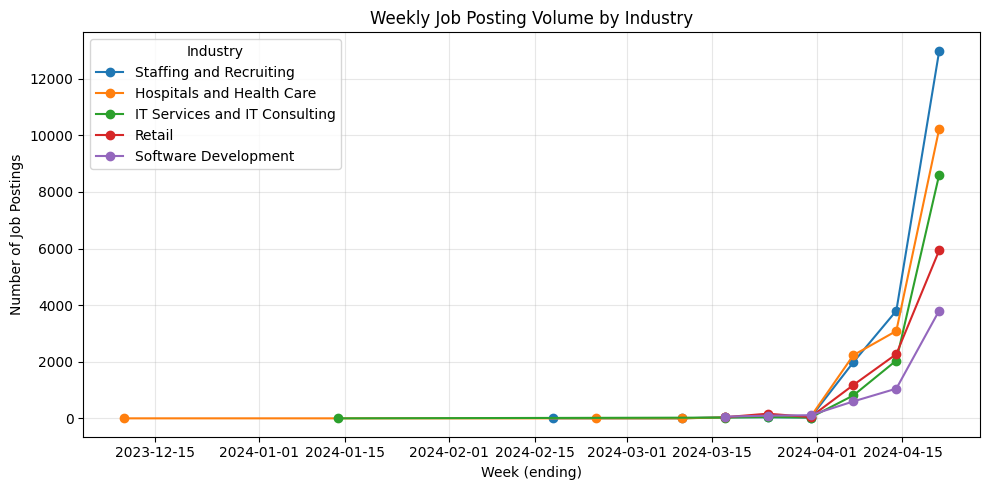

In [61]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 0) Ensure we have a datetime column ----------
if "listed_dt" not in df.columns:
    # Try to build from original_listed_time if available
    if "original_listed_time" in df.columns:
        def _to_dt(val):
            if pd.isna(val): return pd.NaT
            # numeric epoch? auto-detect ms vs s
            try:
                f = float(val)
                unit = "ms" if f > 1e12 else "s"
                return pd.to_datetime(f, unit=unit, errors="coerce", utc=True)
            except Exception:
                return pd.to_datetime(val, errors="coerce", utc=True)
        df["listed_dt"] = df["original_listed_time"].apply(_to_dt)
    else:
        raise ValueError("No 'listed_dt' or 'original_listed_time' column found.")

# ---------- 1) Pick the correct industry source ----------
# Prefer job_industries if present; else fall back to industries
src_col = "job_industries" if "job_industries" in df.columns else ("industries" if "industries" in df.columns else None)
if src_col is None:
    raise ValueError("Neither 'job_industries' nor 'industries' found in df.")

print(f"Using industry column: {src_col}")

# ---------- 2) Parse stringified lists safely ----------
def safe_to_list(x):
    # Already a list?
    if isinstance(x, list): 
        return x
    # Empty / NaN
    if x is None or (isinstance(x, float) and np.isnan(x)) or (isinstance(x, str) and x.strip() == ""):
        return []
    # Try literal_eval
    try:
        v = ast.literal_eval(x)
        if isinstance(v, list):
            return v
        # Sometimes single strings like "'IT Services'": unwrap
        if isinstance(v, str):
            return [v]
    except Exception:
        # Try to split on commas as a last resort
        if isinstance(x, str):
            # remove surrounding brackets/quotes if any
            s = x.strip().strip("[]")
            parts = [p.strip().strip("'").strip('"') for p in s.split(",") if p.strip()]
            return parts
    return []

df["industry_list"] = df[src_col].apply(safe_to_list)

# Quick diagnostics
print("Sample parsed industries:", df["industry_list"].head(5).tolist())

# ---------- 3) Explode rows so each industry gets a row ----------
dfe = df.dropna(subset=["listed_dt"]).copy()
# Ensure datetime is timezone-aware or naive consistently
# (matplotlib handles both; we just keep as-is)
dfe = dfe.explode("industry_list")
# Drop rows where the list was empty
dfe = dfe[dfe["industry_list"].notna() & (dfe["industry_list"].astype(str).str.len() > 0)]

if dfe.empty:
    raise ValueError("After exploding, there are no (date, industry) rows. Check parsing or column content.")

# ---------- 4) Weekly aggregation ----------
weekly_industry = (
    dfe.groupby([pd.Grouper(key="listed_dt", freq="W"), "industry_list"])
      .size()
      .reset_index(name="count")
)

print("Weekly rows:", len(weekly_industry))
print("Weeks span:", weekly_industry["listed_dt"].min(), "→", weekly_industry["listed_dt"].max())
print("Top industries by total rows:")
print(weekly_industry["industry_list"].value_counts().head(10))

# Keep top N industries overall for readability
TOP_N = 5
top_inds = (
    weekly_industry.groupby("industry_list")["count"].sum()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)
weekly_top = weekly_industry[weekly_industry["industry_list"].isin(top_inds)].copy()

# ---------- 5) Plot (pure matplotlib; one line per industry) ----------
plt.figure(figsize=(10, 5))
for ind in top_inds:
    w = weekly_top[weekly_top["industry_list"] == ind].sort_values("listed_dt")
    # markers for weekly points
    plt.plot(w["listed_dt"], w["count"], marker="o", label=ind)

plt.title("Weekly Job Posting Volume by Industry")
plt.xlabel("Week (ending)")
plt.ylabel("Number of Job Postings")
plt.grid(True, alpha=0.3)
plt.legend(title="Industry", loc="best")
plt.tight_layout()
plt.show()


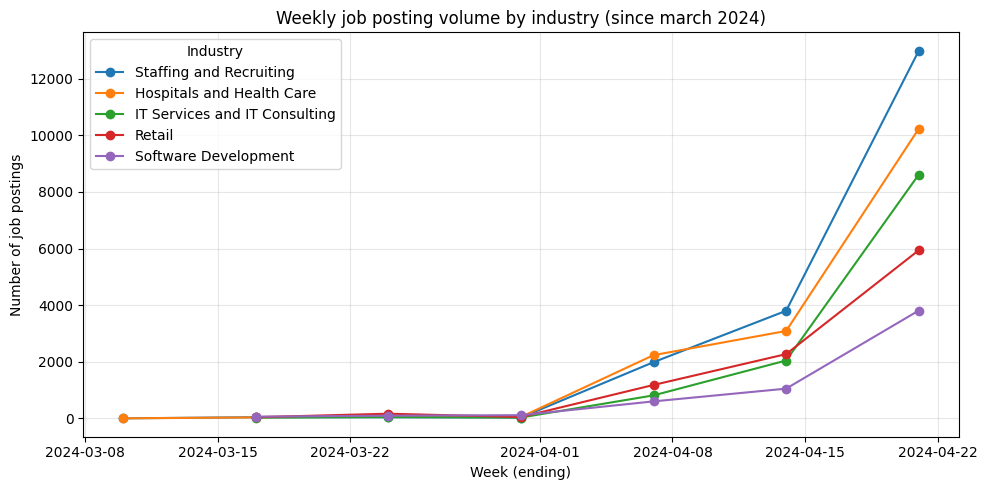

In [66]:
START = "2024-03-01"
tz = weekly_industry["listed_dt"].dt.tz
start_ts = pd.Timestamp(START, tz=tz)

weekly_recent = weekly_industry[weekly_industry["listed_dt"] >= start_ts].copy()

TOP_N = 5
top_inds_recent = (
    weekly_recent.groupby("industry_list")["count"].sum()
    .sort_values(ascending=False).head(TOP_N).index
)
weekly_top_recent = weekly_recent[weekly_recent["industry_list"].isin(top_inds_recent)].copy()

plt.figure(figsize=(10,5))
for ind in top_inds_recent:
    w = weekly_top_recent[weekly_top_recent["industry_list"] == ind].sort_values("listed_dt")
    plt.plot(w["listed_dt"], w["count"], marker="o", label=ind)

plt.title("Weekly job posting volume by industry (since march 2024)")
plt.xlabel("Week (ending)")
plt.ylabel("Number of job postings")
plt.grid(True, alpha=0.3)
plt.legend(title="Industry")
plt.tight_layout()
plt.show()


In [54]:
jobs = pd.read_csv("raw_data/postings.csv", usecols=["job_id", "company_id", "title", "location"])
companies = pd.read_csv("raw_data/companies/companies.csv", usecols=["company_id", "name", "address", "city", "state", "country"])

company_example = companies[companies["name"].str.contains("Amazon", case=False, na=False)].iloc[0]
cid = company_example["company_id"]

print("Company record from companies.csv:")
print(company_example)

print("\nJob posting locations for this company:")
print(jobs[jobs["company_id"] == cid]["location"].value_counts().head(10))

Company record from companies.csv:
company_id             1586
name                 Amazon
state                    WA
country                  US
city                Seattle
address       2127 7th Ave.
Name: 99, dtype: object

Job posting locations for this company:
location
Seattle, WA                72
Bellevue, WA               31
Arlington, VA              19
Austin, TX                 17
New York, United States    15
New York, NY               12
Nashville, TN               9
Westborough, MA             7
Dallas, TX                  7
Boston, MA                  7
Name: count, dtype: int64


Adding companies.csv

In [55]:
companies = pd.read_csv(
    "raw_data/companies/companies.csv",
    usecols=["company_id", "name"]
)

df = df.merge(companies, on="company_id", how="left")

Adding company_industries.csv

In [56]:
company_industries = pd.read_csv("raw_data/companies/company_industries.csv")

company_industries_agg = (
    company_industries
    .dropna(subset=["industry"])
    .groupby("company_id", as_index=False)
    .agg(industries=("industry", lambda x: list(set(x))))
)

df = df.merge(company_industries_agg, on="company_id", how="left")

We implement aggregation because few companies have more than 1 industry (one-to-many relationship).

In [57]:
company_counts = (
    company_industries.groupby("company_id")["industry"]
    .nunique()
    .reset_index(name="n_industries")
)

multi_industry_companies = company_counts[company_counts["n_industries"] > 1]

print(f"Companies with >1 industry: {len(multi_industry_companies)}")

Companies with >1 industry: 10


In [58]:
sample_multi = (
    company_industries[company_industries["company_id"].isin(multi_industry_companies["company_id"].head(5))]
    .sort_values("company_id")
)

print(sample_multi)

       company_id                             industry
2908         4721  International Trade and Development
14958        4721        IT Services and IT Consulting
3361        21792                          Real Estate
9906        21792                   Financial Services
1170        27292              Staffing and Recruiting
9890        27292        IT Services and IT Consulting
793       1687254                        Manufacturing
24142     1687254           Retail Apparel and Fashion
7849      2471716      Food and Beverage Manufacturing
10987     2471716                               Retail


In [59]:
company_industries_agg.loc[company_industries_agg["company_id"] == 21792]

,company_id,industries
2448,21792,"[Real Estate, Financial Services]"


Adding company_specialities.csv

In [10]:
company_specialities = pd.read_csv("raw_data/companies/company_specialities.csv")

company_specialities_agg = (
    company_specialities
    .dropna(subset=["speciality"])
    .groupby("company_id", as_index=False)
    .agg(specialities=("speciality", lambda x: list(set(x))))
)

df = df.merge(company_specialities_agg, on="company_id", how="left")

In [11]:
company_specialities_agg["n_specialities"] = company_specialities_agg["specialities"].apply(len)
top_multi_special = company_specialities_agg.sort_values("n_specialities", ascending=False).head(10)
print(top_multi_special)

       company_id                                       specialities  \
5570       226965  [payroll, Talent Acquisition, Lifesciences, Ou...   
2433        27946  [On Demand, HR, Scaling, Interim CFO, Financia...   
13822    13423341  [Employee, HR, Talent Acquisition, SAP, future...   
17102    86283098  [Clinical Development and Design, Regulatory S...   
12636     9340686  [Mobile Inventory Management, IT Billing, Euro...   
17606    99202927  [FERC, EASEMENTS, ENERGY, DATABASE/DOCUMENT MA...   
9996      2488924  [Advisory, Security Architects, Talent Acquisi...   
5406       202963  [IBM Cognos, Microservices, STIBO, IBM Rationa...   
12230     6650168  [Health, Consulting Services, Social Media, Di...   
6440       425337  [data cleansing, data enhancement, engineering...   

       n_specialities  
5570               84  
2433               81  
13822              77  
17102              65  
12636              60  
17606              58  
9996               57  
5406           

Adding employee_counts.csv

In [12]:
employee_counts = pd.read_csv("raw_data/companies/employee_counts.csv", 
                              usecols=["company_id", "employee_count", "follower_count", "time_recorded"])

employee_counts["time_recorded"] = pd.to_datetime(employee_counts["time_recorded"], errors="coerce")

# Keep the latest record per company
emp_latest = (
    employee_counts
    .sort_values(["company_id", "time_recorded"])
    .dropna(subset=["time_recorded"])
    .groupby("company_id", as_index=False)
    .tail(1)  # last (latest) record per company
    .rename(columns={
        "employee_count": "employee_count_latest",
        "follower_count": "follower_count_latest",
        "time_recorded": "employee_counts_time"
    })
)

df = df.merge(emp_latest[["company_id", "employee_count_latest", "follower_count_latest"]], 
              on="company_id", how="left")


Adding benefits.csv

In [13]:
benefits = pd.read_csv("raw_data/jobs/benefits.csv")

benefits_agg = (
    benefits.dropna(subset=["type"])
    .groupby("job_id", as_index=False)
    .agg(benefits=("type", lambda x: list(set(x))))
)

df = df.merge(benefits_agg, on="job_id", how="left")


Adding jon_industries.csv and industries.csv

In [14]:
job_industries = pd.read_csv("raw_data/jobs/job_industries.csv", usecols=["job_id","industry_id"])
industries = pd.read_csv("raw_data/mappings/industries.csv", usecols=["industry_id","industry_name"])

job_industries["industry_id"] = pd.to_numeric(job_industries["industry_id"], errors="coerce").astype("Int64")
industries["industry_id"]     = pd.to_numeric(industries["industry_id"], errors="coerce").astype("Int64")

ji_named = job_industries.merge(industries, on="industry_id", how="left")

job_industries_agg = (
    ji_named
    .dropna(subset=["industry_name"])
    .groupby("job_id", as_index=False)
    .agg(job_industries=("industry_name", lambda s: sorted(set(s))))
)
df = df.merge(job_industries_agg, on="job_id", how="left")


In [15]:
df[["job_id", "title", "job_industries"]].head(10)


,job_id,title,job_industries
0,921716,Marketing Coordinator,[Real Estate]
1,1829192,Mental Health Therapist/Counselor,NaN
2,10998357,Assitant Restaurant Manager,[Restaurants]
3,23221523,Senior Elder Law / Trusts and Estates Associat...,[Law Practice]
4,35982263,Service Technician,[Facilities Services]
5,91700727,Economic Development and Planning Intern,[Non-profit Organization Management]
6,103254301,Producer,[Design Services]
7,112576855,Building Engineer,"[Food and Beverage Services, Hospitality]"
8,1218575,Respiratory Therapist,[Hospitals and Health Care]
9,2264355,Worship Leader,[Religious Institutions]


Adding job_skills.csv and skills.csv

In [16]:
job_skills = pd.read_csv("raw_data/jobs/job_skills.csv", usecols=["job_id","skill_abr"])
skills = pd.read_csv("raw_data/mappings/skills.csv", usecols=["skill_abr","skill_name"])

js_named = job_skills.merge(skills, on="skill_abr", how="left")

job_skills_agg = (
    js_named
    .dropna(subset=["skill_name"])
    .groupby("job_id", as_index=False)
    .agg(job_skills=("skill_name", lambda s: sorted(set(s))))
)

job_skills_agg["n_job_skills"] = job_skills_agg["job_skills"].apply(len)

df = df.merge(job_skills_agg, on="job_id", how="left")

In [17]:
df[["job_id","title","n_job_skills"]].sort_values("n_job_skills", ascending=False).head(10)

,job_id,title,n_job_skills
21239,3889417724,Graduate Program,3.0
70590,3902839987,Laboratory Technician,3.0
109294,3905354069,Medical Laboratory Scientist/Technologist *Up ...,3.0
70595,3902840550,Project Delivery Specialist- Epic Support Spec...,3.0
70596,3902840554,Senior Salesforce Developer,3.0
52964,3901631742,"Assistant Store Manager - Westbury, NY",3.0
15021,3887887009,MANAGER with Security Clearance,3.0
70601,3902840629,Principal Architect,3.0
70603,3902840632,Architect 1_USD,3.0
32522,3894916703,Area Director,3.0


In [18]:
df.loc[df["job_id"] == 3898170505, ["title","job_skills"]]

,title,job_skills
40010,Transportation Specialist,"[Distribution, Manufacturing, Supply Chain]"


Adding salaries.csv

In [19]:
salaries = pd.read_csv(
    "raw_data/jobs/salaries.csv",
    usecols=["job_id","max_salary","min_salary","pay_period","currency"]
)

Lets check how many currencies we have and lets drop other than USD.

In [20]:
print(salaries["currency"].value_counts(dropna=False))

currency
USD    40770
EUR        6
CAD        3
BBD        2
AUD        2
GBP        2
Name: count, dtype: int64


Since we have hourly/yearly/monthly/weekly salary pay-periods, we have to normalize it.  

In [21]:

# ========= 1) Load salaries & keep USD only =========
salaries = pd.read_csv(
    "raw_data/jobs/salaries.csv",
    usecols=["job_id", "max_salary", "min_salary", "pay_period", "currency"]
)
salaries = salaries[salaries["currency"] == "USD"].copy()

# ========= 2) Normalize pay period labels =========
pp = salaries["pay_period"].astype(str).str.upper().str.strip()
pp = pp.replace({
    # YEAR variants
    "YEARLY": "YEAR", "PER_YEAR": "YEAR", "ANNUAL": "YEAR", "YR": "YEAR", "Y": "YEAR",
    # HOUR variants
    "HOURLY": "HOUR", "PER_HOUR": "HOUR", "HR": "HOUR", "H": "HOUR",
    # MONTH variants
    "MONTHLY": "MONTH", "PER_MONTH": "MONTH", "MO": "MONTH", "M": "MONTH",
    # WEEK variants
    "WEEKLY": "WEEK", "PER_WEEK": "WEEK", "WK": "WEEK", "W": "WEEK",
    # BIWEEKLY variants
    "BI-WEEKLY": "BIWEEKLY", "BI WEEKLY": "BIWEEKLY",
    # (optional) DAY variants if present
    "DAILY": "DAY", "PER_DAY": "DAY", "D": "DAY"
})
salaries["pay_period_norm"] = pp

# ========= 3) Annualization factors =========
factor_map = {
    "YEAR": 1.0,
    "HOUR": 2080.0,     # 40h * 52w
    "WEEK": 52.0,
    "BIWEEKLY": 26.0,
    "MONTH": 12.0,
    "DAY": 260.0        # ~5d * 52w (adjust if needed)
}
salaries["factor"] = salaries["pay_period_norm"].map(factor_map)

# ========= 4) Create normalized salary columns (USD/year) =========
salaries["min_salary_norm"] = np.where(
    salaries["factor"].notna() & salaries["min_salary"].notna(),
    salaries["min_salary"] * salaries["factor"],
    np.nan
)
salaries["max_salary_norm"] = np.where(
    salaries["factor"].notna() & salaries["max_salary"].notna(),
    salaries["max_salary"] * salaries["factor"],
    np.nan
)

# ========= 5) Ensure one row per job_id on salaries side =========
# If a job_id appears multiple times (e.g., duplicate rows), compress by taking non-null max
salaries_norm = (
    salaries[["job_id", "min_salary_norm", "max_salary_norm"]]
    .groupby("job_id", as_index=False)
    .agg(min_salary_norm=("min_salary_norm", "max"),
         max_salary_norm=("max_salary_norm", "max"))
)
assert salaries_norm["job_id"].is_unique

# ========= 6) (Recommended) collapse df to one row per job_id =========
# We keep first non-null for scalar columns and union for any list-like columns.

def is_list_col(series: pd.Series) -> bool:
    return series.apply(lambda x: isinstance(x, list)).any()

list_cols = [c for c in df.columns if is_list_col(df[c])]
scalar_cols = [c for c in df.columns if c not in list_cols]

# first non-null for scalars
df_scalar = (
    df.sort_values("job_id")
      .groupby("job_id", as_index=False)[scalar_cols]
      .first()
)

# union lists for list columns (if any)
def union_lists(series):
    bag = []
    for v in series:
        if isinstance(v, list):
            bag.extend(v)
    return sorted(set(bag)) if bag else np.nan

if list_cols:
    df_lists = df.groupby("job_id")[list_cols].agg(union_lists).reset_index()
    df_unique = df_scalar.merge(df_lists, on="job_id", how="left")
else:
    df_unique = df_scalar

assert df_unique["job_id"].is_unique

# ========= 7) Drop any old salary columns & merge cleanly =========
df_unique = df_unique.drop(columns=["min_salary_norm", "max_salary_norm", "avg_salary_norm"], errors="ignore")
df_unique = df_unique.merge(salaries_norm, on="job_id", how="left", validate="one_to_one")

# One handy number to plot
df_unique["avg_salary_norm"] = df_unique[["min_salary_norm", "max_salary_norm"]].mean(axis=1, skipna=True)

# ========= 8) Coverage report =========
have_any = (df_unique["min_salary_norm"].notna() | df_unique["max_salary_norm"].notna()).sum()
print(f"Jobs with any normalized salary: {have_any} ({have_any/len(df_unique):.1%})")

# If you want df to be this deduped/merged version from now on:
df = df_unique

df = df.drop(columns=["min_salary", "max_salary"], errors="ignore")


Jobs with any normalized salary: 29778 (24.0%)


In [22]:
print(df.shape)           
print(df.columns.tolist())  
df.info()                 
df.head(10)              

(123849, 18)
['job_id', 'title', 'location', 'company_id', 'work_type', 'fips', 'name', 'employee_count_latest', 'follower_count_latest', 'n_job_skills', 'industries', 'specialities', 'benefits', 'job_industries', 'job_skills', 'min_salary_norm', 'max_salary_norm', 'avg_salary_norm']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_id                 123849 non-null  int64  
 1   title                  123849 non-null  object 
 2   location               123849 non-null  object 
 3   company_id             122132 non-null  float64
 4   work_type              123849 non-null  object 
 5   fips                   96434 non-null   float64
 6   name                   122130 non-null  object 
 7   employee_count_latest  122131 non-null  float64
 8   follower_count_latest  122131 non-null  float64
 9   n_job_skills    

,job_id,title,location,company_id,work_type,fips,name,employee_count_latest,follower_count_latest,n_job_skills,industries,specialities,benefits,job_industries,job_skills,min_salary_norm,max_salary_norm,avg_salary_norm
0,921716,Marketing Coordinator,"Princeton, NJ",2774458.0,FULL_TIME,34021.0,Corcoran Sawyer Smith,402.0,2351.0,2.0,[Real Estate],"[new development, real estate]",NaN,[Real Estate],"[Marketing, Sales]",35360.0,41600.0,38480.0
1,1218575,Respiratory Therapist,"Omaha, NE",721189.0,FULL_TIME,31055.0,Children's Nebraska,1793.0,13313.0,1.0,[Hospitals and Health Care],"[Cardiology, Critical Care, Developmental Pedi...",NaN,[Hospitals and Health Care],[Health Care Provider],NaN,NaN,NaN
2,1829192,Mental Health Therapist/Counselor,"Fort Collins, CO",NaN,FULL_TIME,8069.0,None,NaN,NaN,1.0,NaN,NaN,NaN,NaN,[Health Care Provider],62400.0,104000.0,83200.0
3,2264355,Worship Leader,"Palm Bay, FL",28631247.0,PART_TIME,12009.0,Bay West Church,1.0,3.0,3.0,[Religious Institutions],"[Biblical preaching, Discipling/mentoring, Kid...",NaN,[Religious Institutions],"[Art/Creative, Design, Information Technology]",NaN,NaN,NaN
4,9615617,Inside Customer Service Associate,"Saginaw, MI",1194336.0,FULL_TIME,26145.0,"Glastender, Inc.",72.0,1490.0,NaN,[Food and Beverage Services],"[Manufacturing, bar designs, commercial bar eq...",NaN,[Beverage Manufacturing],NaN,NaN,NaN,NaN
5,10998357,Assitant Restaurant Manager,"Cincinnati, OH",64896719.0,FULL_TIME,39061.0,The National Exemplar,15.0,40.0,2.0,[Restaurants],NaN,NaN,[Restaurants],"[Management, Manufacturing]",45000.0,65000.0,55000.0
6,11009123,Project Architect,"St Louis, MO",93456.0,FULL_TIME,29183.0,PGAV Destinations,129.0,5458.0,3.0,[Architecture and Planning],"[Animal Care, Architecture, Attraction Design,...",NaN,[Architecture and Planning],"[Art/Creative, Design, Information Technology]",NaN,NaN,NaN
7,23221523,Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",766262.0,FULL_TIME,36059.0,"Abrams Fensterman, LLP",222.0,2427.0,1.0,[Law Practice],"[Appellate, Civil Litigation, Corporate & Secu...",[401(k)],[Law Practice],[Other],140000.0,175000.0,157500.0
8,35982263,Service Technician,"Burlington, IA",NaN,FULL_TIME,19057.0,None,NaN,NaN,1.0,NaN,NaN,NaN,[Facilities Services],[Information Technology],60000.0,80000.0,70000.0
9,56482768,Appalachian Highlands Women's Business Center,"Kingsport, TN",NaN,FULL_TIME,47163.0,None,NaN,NaN,NaN,NaN,NaN,"[401(k), Dental insurance, Disability insurance]",[Non-profit Organizations],NaN,NaN,NaN,NaN


Normalized_salary in postings.csv is not correct for few entries (for example salary = 21), that is why we need to implement our own code to normalize salaries.

In [23]:
postings_check = pd.read_csv(
    "raw_data/postings.csv",
    usecols=["job_id", "title", "location", "normalized_salary"]
)

postings_check[postings_check["normalized_salary"] == 21.0].head(10)

,job_id,title,location,normalized_salary
17358,3888031616,Corporate Communications/HR Employee Branding ...,"Crystal Lake, IL",21.0
32764,3894945845,Medical Assistant,"Washington, DC",21.0
34501,3895491215,Front Desk Program Assistant,"Washington, DC",21.0
41629,3899525788,Service Center Associate,"San Diego, CA",21.0
51233,3901382548,"Project Support Administrator, Pathology Support","Aliso Viejo, CA",21.0
58226,3901948617,Bilingual (English and Korean) Operations Anal...,"Berkeley, CA",21.0
63413,3902348724,Installation Technician,"Lancaster, PA",21.0
74377,3902959366,Call Center Representative,"Boston, MA",21.0
92393,3904584162,Business Specialist,Omaha Metropolitan Area,21.0
100736,3905226877,Wholesale Operations and Marketing Coordinator,"Houston, TX",21.0


Using GeoJSON. FIPS codes are standardized as 5-digit strings, GeoJSON expects that exact format. FIPS codes are valid only for the USA.
TO DO is to plot jobs outside of the USA using "location".

In [24]:
total_jobs = len(df)

us_jobs = df["fips"].notna().sum()

print(f"Total jobs: {total_jobs:,}")
print(f"Jobs in US (with FIPS): {us_jobs:,}")
print(f"Share in US: {us_jobs/total_jobs:.1%}")

Total jobs: 123,849
Jobs in US (with FIPS): 96,434
Share in US: 77.9%


In [25]:
df["fips"] = df["fips"].dropna().astype(int).astype(str).str.zfill(5)

jobs_by_county = (
    df.groupby("fips")
    .size()
    .reset_index(name="job_count")
)


In [26]:
import plotly.express as px
import json

with open("geojson-counties-fips.json") as f:
    counties = json.load(f)

fig = px.choropleth(
    jobs_by_county,
    geojson=counties,
    locations="fips", 
    color="job_count",
    color_continuous_scale="Viridis",
    scope="usa",
    labels={"job_count": "Jobs"}
)
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'geojson-counties-fips.json'

Saving new df as new .csv table

In [28]:
import os

os.makedirs("processed_data", exist_ok=True)
df.to_csv("processed_data/clean_dataset.csv", index=False)
